# RL Exper

In [1]:
# !pip install stable-baselines3 --default-timeout=100

In [2]:
# train_uniswap_simple.py
# -----------------------
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

# ───── your environment ─────
from env_nikolai3 import UniswapV3LPGymEnv
from config.env_config import Config

# ───── RL + utils ─────
import gymnasium as gym
from gymnasium.wrappers import TimeLimit, RecordEpisodeStatistics, FlattenObservation
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.evaluation import evaluate_policy
import matplotlib.pyplot as plt
import pandas as pd
import datetime as dt

# ───── hyper‑params you might tweak ─────
TOTAL_TIMESTEPS      = 10_000     # training steps
MAX_EPISODE_MINUTES  = 1_000     # one‑day cap

# ╭────────────────────────── helpers ───────────────────────────╮
def make_env():
    cfg = Config()
    env = UniswapV3LPGymEnv(cfg, feat_num=19)

    env = TimeLimit(env, max_episode_steps=MAX_EPISODE_MINUTES)
    env = RecordEpisodeStatistics(env)
    env = FlattenObservation(env)

    logs_dir = Path("logs");  logs_dir.mkdir(exist_ok=True)
    env = Monitor(env, str(logs_dir), allow_early_resets=True)   # ← str() fix
    return env


def plot_learning_curve(monitor_csv: Path, title: str = "Learning curve") -> None:
    df = pd.read_csv(monitor_csv, comment="#")
    df["rolling_return"] = df["r"].rolling(window=20).mean()
    plt.figure(figsize=(8, 4))
    plt.plot(df["l"], df["rolling_return"])
    plt.xlabel("Episode"); plt.ylabel("Reward (20‑ep MA)")
    plt.title(title); plt.grid(True)
    plt.tight_layout(); plt.show()


# ╭────────────────────────── training ──────────────────────────╮
def main():
    # 1⃣  make vectorised env
    env = DummyVecEnv([make_env])

    # 2⃣  define agent
    model = PPO(
        "MlpPolicy",
        env,
        # n_steps       = 2048,
        n_steps       = 1024,
        batch_size    = 256,
        gae_lambda    = 0.95,
        gamma         = 0.999,
        learning_rate = 3e-4,
        clip_range    = 0.2,
        vf_coef       = 0.5,
        ent_coef      = 0.0,
        verbose       = 1,
        # tensorboard_log="tensorboard",
        device="auto",
    )

    # 3⃣  learn
    model.learn(total_timesteps=TOTAL_TIMESTEPS, progress_bar=True)

    # 4⃣  save & evaluate
    ts = dt.datetime.now().strftime("%Y%m%d_%H%M")
    model_path = Path("models"); model_path.mkdir(exist_ok=True)
    fname = model_path / f"ppo_uniswap_{ts}"
    model.save(fname)
    print(f"\n✔️  Saved model to {fname}.zip")

    mean_r, std_r = evaluate_policy(model, env, n_eval_episodes=10)
    print(f"Evaluation over 10 eps → mean ± std reward: {mean_r:.2f} ± {std_r:.2f}")

    # 5⃣  plot learning curve
    monitors = sorted(Path("logs").glob("*.monitor.csv"))
    if monitors:
        plot_learning_curve(monitors[-1], title="PPO on Uniswap‑V3 LP env")
    else:
        print("No monitor file found ‑ nothing to plot.")


if __name__ == "__main__":  
    main()

Using cpu device


Output()

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | -26      |
| time/              |          |
|    fps             | 28       |
|    iterations      | 1        |
|    time_elapsed    | 36       |
|    total_timesteps | 1024     |
---------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1e+03       |
|    ep_rew_mean          | -17         |
| time/                   |             |
|    fps                  | 28          |
|    iterations           | 2           |
|    time_elapsed         | 73          |
|    total_timesteps      | 2048        |
| train/                  |             |
|    approx_kl            | 0.009640139 |
|    clip_fraction        | 0.109       |
|    clip_range           | 0.2         |
|    entropy_loss         | -4.25       |
|    explained_variance   | 0.0722      |
|    learning_rate        | 0.0003      |
|    loss                 | 0.111       |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0146     |
|    std                  | 0.994       |
|    value_loss           | 0.245       |
-----------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1e+03       |
|    ep_rew_mean          | -12         |
| time/                   |             |
|    fps                  | 29          |
|    iterations           | 3           |
|    time_elapsed         | 103         |
|    total_timesteps      | 3072        |
| train/                  |             |
|    approx_kl            | 0.004903771 |
|    clip_fraction        | 0.0528      |
|    clip_range           | 0.2         |
|    entropy_loss         | -4.23       |
|    explained_variance   | -0.188      |
|    learning_rate        | 0.0003      |
|    loss                 | 0.0204      |
|    n_updates            | 20          |
|    policy_gradient_loss | -0.00771    |
|    std                  | 0.988       |
|    value_loss           | 0.101       |
-----------------------------------------


...

------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 1e+03        |
|    ep_rew_mean          | -10.9        |
| time/                   |              |
|    fps                  | 27           |
|    iterations           | 7            |
|    time_elapsed         | 258          |
|    total_timesteps      | 7168         |
| train/                  |              |
|    approx_kl            | 0.0031358937 |
|    clip_fraction        | 0.0165       |
|    clip_range           | 0.2          |
|    entropy_loss         | -4.19        |
|    explained_variance   | 0.0119       |
|    learning_rate        | 0.0003       |
|    loss                 | 0.0591       |
|    n_updates            | 60           |
|    policy_gradient_loss | -0.0026      |
|    std                  | 0.976        |
|    value_loss           | 0.113        |
------------------------------------------


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 1e+03        |
|    ep_rew_mean          | -10.2        |
| time/                   |              |
|    fps                  | 27           |
|    iterations           | 8            |
|    time_elapsed         | 294          |
|    total_timesteps      | 8192         |
| train/                  |              |
|    approx_kl            | 0.0099334195 |
|    clip_fraction        | 0.125        |
|    clip_range           | 0.2          |
|    entropy_loss         | -4.18        |
|    explained_variance   | 0.0442       |
|    learning_rate        | 0.0003       |
|    loss                 | 0.0191       |
|    n_updates            | 70           |
|    policy_gradient_loss | -0.0123      |
|    std                  | 0.973        |
|    value_loss           | 0.0648       |
------------------------------------------


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 1e+03        |
|    ep_rew_mean          | -9.22        |
| time/                   |              |
|    fps                  | 28           |
|    iterations           | 9            |
|    time_elapsed         | 326          |
|    total_timesteps      | 9216         |
| train/                  |              |
|    approx_kl            | 0.0068466226 |
|    clip_fraction        | 0.0862       |
|    clip_range           | 0.2          |
|    entropy_loss         | -4.17        |
|    explained_variance   | 0.0835       |
|    learning_rate        | 0.0003       |
|    loss                 | 0.0361       |
|    n_updates            | 80           |
|    policy_gradient_loss | -0.00788     |
|    std                  | 0.972        |
|    value_loss           | 0.083        |
------------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1e+03       |
|    ep_rew_mean          | -8.5        |
| time/                   |             |
|    fps                  | 28          |
|    iterations           | 10          |
|    time_elapsed         | 361         |
|    total_timesteps      | 10240       |
| train/                  |             |
|    approx_kl            | 0.009186583 |
|    clip_fraction        | 0.0792      |
|    clip_range           | 0.2         |
|    entropy_loss         | -4.16       |
|    explained_variance   | -0.000521   |
|    learning_rate        | 0.0003      |
|    loss                 | 0.0255      |
|    n_updates            | 90          |
|    policy_gradient_loss | -0.00254    |
|    std                  | 0.968       |
|    value_loss           | 0.0485      |
-----------------------------------------



✔️  Saved model to models\ppo_uniswap_20250512_0413.zip
Evaluation over 10 eps → mean ± std reward: 0.00 ± 0.00
No monitor file found ‑ nothing to plot.


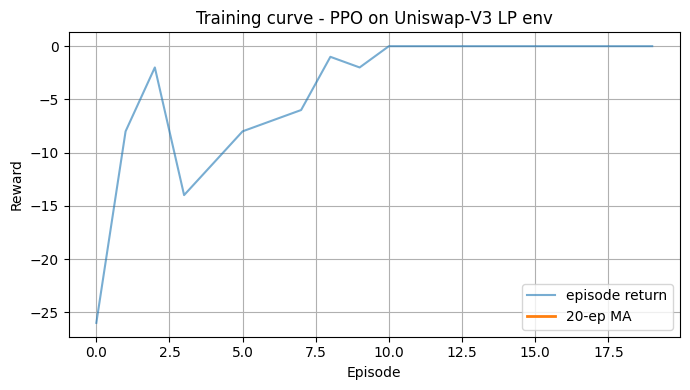

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


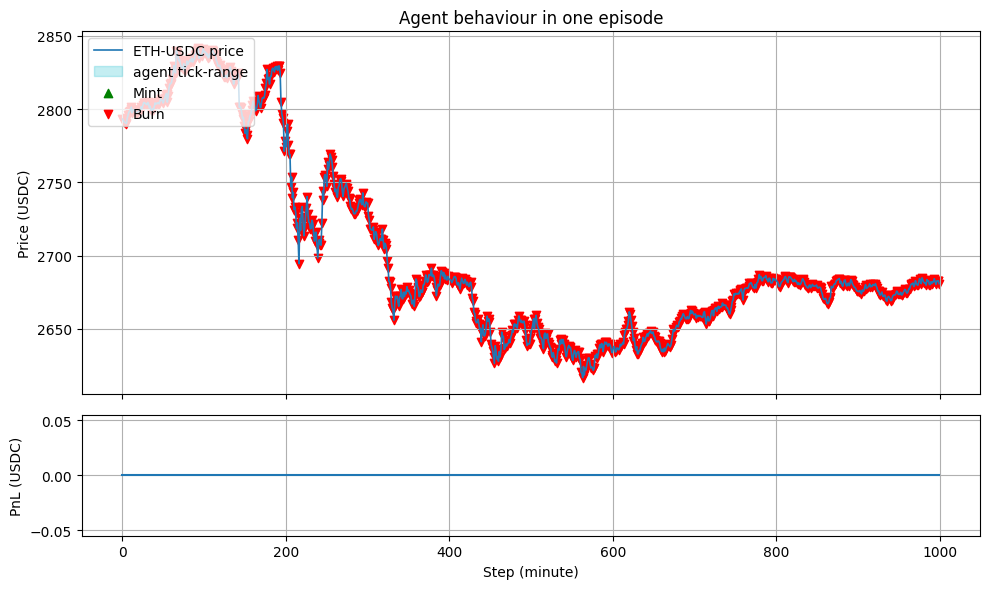

Raw actions from policy (shape (1000, 3)):
[[ 0.     0.022 -0.001]
 [ 0.     0.022 -0.001]
 [ 0.     0.022 -0.001]
 ...
 [ 0.     0.022 -0.001]
 [ 0.     0.022 -0.001]
 [ 0.     0.022 -0.001]]


In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
import torch

def tick_to_price(tick: int) -> float:
    sqrtp = 1.0001 ** (tick / 2)
    return sqrtp ** 2


def plot_learning_curve(log_dir: Path):
    """Plot episodic returns + 20‑episode moving average."""
    mon_csv = sorted(log_dir.glob("monitor.csv"))[-1]
    df = pd.read_csv(mon_csv, comment="#")
    ep_returns = df["r"].to_numpy()
    ma = pd.Series(ep_returns).rolling(20).mean()

    plt.figure(figsize=(7, 4))
    plt.plot(ep_returns, label="episode return", alpha=0.6)
    plt.plot(ma, label="20‑ep MA", linewidth=2)
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.title("Training curve - PPO on Uniswap‑V3 LP env")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def run_episode_and_plot(model, env):
    """Roll one episode, record price / actions, then plot & print actions."""
    obs, _ = env.reset()

    prices, plow, phigh = [], [], []
    mints_x, mints_y, burns_x, burns_y = [], [], [], []
    cum_pnl = []
    actions_out = []

    done = False
    step = 0
    while not done and step < env.EPISODE_LEN:
        ts = env.decision_grid[env.idx]
        p = env._eth_price(ts)

        action, _ = model.predict(obs, deterministic=True)
        actions_out.append(action.copy()) 

        obs, reward, done, trunc, info = env.step(action)

        prices.append(p)
        if env.active:
            plow.append(tick_to_price(env.tick_l))
            phigh.append(tick_to_price(env.tick_u))
        else:
            plow.append(np.nan)
            phigh.append(np.nan)

        if int(action[0]) == 1:  # Mint
            mints_x.append(step)
            mints_y.append(p)
        elif int(action[0]) == 0 and env.active is False:  # Burn
            burns_x.append(step)
            burns_y.append(p)

        cum_pnl.append(env.cumulative_pnl)
        step += 1

    t = np.arange(len(prices))

    fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                            gridspec_kw={"height_ratios": [3, 1]})

    axs[0].plot(t, prices, label="ETH‑USDC price", linewidth=1.2)
    axs[0].fill_between(t, plow, phigh, color="tab:cyan", alpha=0.25,
                        label="agent tick‑range")
    axs[0].scatter(mints_x, mints_y, marker="^", color="green", label="Mint")
    axs[0].scatter(burns_x, burns_y, marker="v", color="red", label="Burn")
    axs[0].set_ylabel("Price (USDC)")
    axs[0].set_title("Agent behaviour in one episode")
    axs[0].legend(loc="upper left")
    axs[0].grid(True)

    # (b) cumulative PnL
    axs[1].plot(t, cum_pnl, label="cumulative PnL")
    axs[1].set_ylabel("PnL (USDC)")
    axs[1].set_xlabel("Step (minute)")
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

    actions_arr = np.array(actions_out)
    print("Raw actions from policy (shape %s):" % (actions_arr.shape,))
    np.set_printoptions(precision=3, suppress=True)
    print(actions_arr)


if __name__ == "__main__":
    LOG_DIR = Path("logs")
    MODEL_DIR = Path("models")

    plot_learning_curve(LOG_DIR)

    latest_model = sorted(MODEL_DIR.glob("ppo_uniswap_*.zip"))[-1]
    from stable_baselines3 import PPO
    from env_nikolai2 import UniswapV3LPGymEnv
    from config.env_config import Config

    env = UniswapV3LPGymEnv(Config(), feat_num=19)
    env.EPISODE_LEN = 1000  # IMPORTANT

    model = PPO.load(latest_model, env=env)
    run_episode_and_plot(model, env)